In [1]:
!pip install seaborn


[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set(style="whitegrid")

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "notebooks" / "results" / "raw_runs"
FINAL_DIR = PROJECT_ROOT / "notebooks" / "results" / "final_analysis"

FINAL_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED_DATASETS = [
    "australian_electricity_demand",
    "m1_quarterly",
    "m4_quarterly",
    "solar_10_minutes",
]

FOUNDATION_MODELS = ["timesfm", "ttm", "uni2ts"]
TRADITIONAL_MODELS = ["naive", "seasonal_naive", "arima", "prophet", "lstm"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("FINAL_DIR:", FINAL_DIR)

PROJECT_ROOT: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti
RAW_DIR: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/notebooks/results/raw_runs
FINAL_DIR: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/notebooks/results/final_analysis


In [4]:
raw_files = list(RAW_DIR.rglob("*.csv"))

raw_results = []

for file in raw_files:
    if "_baseline.csv" in file.name or "_tuned.csv" in file.name:
        df = pd.read_csv(file)
        df["source_file"] = str(file)
        df["experiment_type"] = "tuned" if "_tuned.csv" in file.name else "baseline"
        raw_results.append(df)

if not raw_results:
    raise FileNotFoundError("No baseline or tuned CSV files found in RAW_DIR.")

raw_df = pd.concat(raw_results, ignore_index=True)

raw_df = raw_df[
    ~raw_df["dataset_key"].isin(EXCLUDED_DATASETS)
].copy()

print("Raw shape:", raw_df.shape)
print("\nExperiment counts:")
print(raw_df["experiment_type"].value_counts())

print("\nDatasets:")
print(sorted(raw_df["dataset_key"].unique()))

print("\nModels:")
print(sorted(raw_df["model"].unique()))

Raw shape: (131104, 56)

Experiment counts:
experiment_type
baseline    65552
tuned       65552
Name: count, dtype: int64

Datasets:
['bitcoin', 'car_parts', 'electricity_weekly', 'fred_md', 'm1_monthly', 'nn5_daily', 'nn5_weekly', 'saugeenday', 'solar_weekly']

Models:
['arima', 'lstm', 'naive', 'prophet', 'seasonal_naive', 'timesfm', 'ttm', 'uni2ts']


In [5]:
successful_df = raw_df.copy()

if "status" in successful_df.columns:
    successful_df = successful_df[successful_df["status"] == "success"].copy()

successful_df = successful_df[
    successful_df["mae"].notna()
    & successful_df["rmse"].notna()
    & successful_df["smape"].notna()
].copy()

successful_df["model_family"] = successful_df["model"].apply(
    lambda x: "foundation" if x in FOUNDATION_MODELS else "traditional"
)

print("Successful shape:", successful_df.shape)
successful_df.head()

Successful shape: (118658, 57)


,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,inference_time_seconds,series_total_time_seconds,status,error_message,resolved_horizon,original_resolved_horizon,horizon_strategy,horizon_type,experiment_type,model_params_json,order,total_runtime_seconds,runtime_per_series_seconds,peak_memory_mb,n_series_evaluated,source_file,input_window,hidden_size,num_layers,epochs,batch_size,learning_rate,device,seasonal_period,model_name,context_length,num_samples,model_path,normalized_frequency,max_context,prefer_longer_context,prefer_l1_loss,yearly_seasonality,weekly_seasonality,daily_seasonality,max_horizon,normalize_inputs,use_continuous_quantile_head,force_flip_invariance,infer_is_positive,fix_quantile_crossing,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,seasonality_mode,growth,model_family
1507,T1,electricity_weekly,energy,weekly,ttm,4,6360.487390,6367.233448,129.811142,2.145767e-06,2.482035,2.482041,success,NaN,4,8,metadata,short,baseline,{},NaN,402.115863,1.252697,2.95701,321,/Users/kunalgurung/Desktop/UTS SEM4/36127/foun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ibm-granite/granite-timeseries-ttm-r2,weekly,512.0,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foundation
1508,T2,electricity_weekly,energy,weekly,ttm,4,4614.655361,4638.234042,25.535247,7.152557e-07,1.158726,1.158730,success,NaN,4,8,metadata,short,baseline,{},NaN,402.115863,1.252697,2.95701,321,/Users/kunalgurung/Desktop/UTS SEM4/36127/foun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ibm-granite/granite-timeseries-ttm-r2,weekly,512.0,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foundation
1509,T3,electricity_weekly,energy,weekly,ttm,4,697.990269,771.796744,41.974870,9.536743e-07,1.239490,1.239495,success,NaN,4,8,metadata,short,baseline,{},NaN,402.115863,1.252697,2.95701,321,/Users/kunalgurung/Desktop/UTS SEM4/36127/foun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ibm-granite/granite-timeseries-ttm-r2,weekly,512.0,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foundation
1510,T4,electricity_weekly,energy,weekly,ttm,4,24855.367448,25068.590102,29.961859,1.192093e-06,1.315824,1.315828,success,NaN,4,8,metadata,short,baseline,{},NaN,402.115863,1.252697,2.95701,321,/Users/kunalgurung/Desktop/UTS SEM4/36127/foun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ibm-granite/granite-timeseries-ttm-r2,weekly,512.0,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foundation
1511,T5,electricity_weekly,energy,weekly,ttm,4,14408.435666,14538.156397,36.132621,1.907349e-06,1.303667,1.303673,success,NaN,4,8,metadata,short,baseline,{},NaN,402.115863,1.252697,2.95701,321,/Users/kunalgurung/Desktop/UTS SEM4/36127/foun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ibm-granite/granite-timeseries-ttm-r2,weekly,512.0,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foundation


In [6]:
accuracy_experiment_df = (
    successful_df
    .groupby(
        [
            "dataset_key",
            "domain",
            "frequency",
            "model",
            "model_family",
            "horizon_type",
            "horizon",
            "experiment_type",
        ],
        dropna=False,
    )
    .agg(
        n_series=("series_id", "nunique"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
    )
    .reset_index()
)

accuracy_experiment_df = accuracy_experiment_df.sort_values(
    ["dataset_key", "horizon_type", "experiment_type", "smape"]
).reset_index(drop=True)

print("Aggregated shape:", accuracy_experiment_df.shape)
accuracy_experiment_df.head(20)

Aggregated shape: (280, 16)


,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb
0,bitcoin,finance,daily,timesfm,foundation,long,30,baseline,18,2.324739e+18,2.411559e+18,20.583393,1.748933e-04,0.454365,0.454548,0.102420
1,bitcoin,finance,daily,ttm,foundation,long,30,baseline,18,1.898523e+18,1.982594e+18,21.082188,3.192160e-06,0.110597,0.110605,0.988549
2,bitcoin,finance,daily,arima,traditional,long,30,baseline,18,1.058520e+18,1.183484e+18,21.356206,1.629194e-06,0.225946,0.225951,15.732830
3,bitcoin,finance,daily,naive,traditional,long,30,baseline,18,7.777283e+17,9.419842e+17,21.785472,8.344650e-07,0.000012,0.000015,0.041874
4,bitcoin,finance,daily,seasonal_naive,traditional,long,30,baseline,18,1.773389e+18,1.963737e+18,22.063132,6.887648e-07,0.000106,0.000109,0.049374
5,bitcoin,finance,daily,prophet,traditional,long,30,baseline,18,4.058407e+18,4.093151e+18,44.091708,1.237260e-04,1.860583,1.860712,143.096272
6,bitcoin,finance,daily,uni2ts,foundation,long,30,baseline,18,3.470404e+18,3.553398e+18,48.327242,2.768305e-06,1.159490,1.159498,0.875642
7,bitcoin,finance,daily,lstm,traditional,long,30,baseline,18,5.326949e+18,5.353397e+18,144.853794,5.788273e-06,12.570681,12.570695,2.315244
8,bitcoin,finance,daily,timesfm,foundation,long,30,tuned,18,2.324739e+18,2.411559e+18,20.583393,2.197822e-04,0.731284,0.731510,0.109180
9,bitcoin,finance,daily,ttm,foundation,long,30,tuned,18,1.878327e+18,1.958246e+18,20.794301,3.298124e-06,0.141125,0.141134,0.991271


In [7]:
baseline_df = accuracy_experiment_df[
    accuracy_experiment_df["experiment_type"] == "baseline"
].copy()

tuned_df = accuracy_experiment_df[
    accuracy_experiment_df["experiment_type"] == "tuned"
].copy()

print("Baseline shape:", baseline_df.shape)
print("Tuned shape:", tuned_df.shape)

display(baseline_df.head())
display(tuned_df.head())

Baseline shape: (140, 16)
Tuned shape: (140, 16)


,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb
0,bitcoin,finance,daily,timesfm,foundation,long,30,baseline,18,2.324739e+18,2.411559e+18,20.583393,1.748933e-04,0.454365,0.454548,0.102420
1,bitcoin,finance,daily,ttm,foundation,long,30,baseline,18,1.898523e+18,1.982594e+18,21.082188,3.192160e-06,0.110597,0.110605,0.988549
2,bitcoin,finance,daily,arima,traditional,long,30,baseline,18,1.058520e+18,1.183484e+18,21.356206,1.629194e-06,0.225946,0.225951,15.732830
3,bitcoin,finance,daily,naive,traditional,long,30,baseline,18,7.777283e+17,9.419842e+17,21.785472,8.344650e-07,0.000012,0.000015,0.041874
4,bitcoin,finance,daily,seasonal_naive,traditional,long,30,baseline,18,1.773389e+18,1.963737e+18,22.063132,6.887648e-07,0.000106,0.000109,0.049374


,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb
8,bitcoin,finance,daily,timesfm,foundation,long,30,tuned,18,2.324739e+18,2.411559e+18,20.583393,2.197822e-04,0.731284,0.731510,0.109180
9,bitcoin,finance,daily,ttm,foundation,long,30,tuned,18,1.878327e+18,1.958246e+18,20.794301,3.298124e-06,0.141125,0.141134,0.991271
10,bitcoin,finance,daily,naive,traditional,long,30,tuned,18,7.777283e+17,9.419842e+17,21.785472,1.059638e-06,0.000012,0.000015,0.041874
11,bitcoin,finance,daily,seasonal_naive,traditional,long,30,tuned,18,1.773389e+18,1.963737e+18,22.063132,9.139379e-07,0.000117,0.000120,0.049374
12,bitcoin,finance,daily,arima,traditional,long,30,tuned,18,1.548943e+18,1.640359e+18,29.214567,1.708666e-06,1.046057,1.046062,37.667662


In [8]:
def add_rank_column(
    df: pd.DataFrame,
    group_cols: list[str],
    value_col: str,
    rank_col: str,
    ascending: bool = True,
) -> pd.DataFrame:
    """
    Add rank column within defined groups.
    Lower rank is better when ascending=True.
    """
    out = df.copy()
    out[rank_col] = out.groupby(group_cols)[value_col].rank(
        method="min",
        ascending=ascending
    )
    return out


def plot_heatmap(
    pivot_df: pd.DataFrame,
    title: str,
    cmap: str = "RdYlGn_r",
    fmt: str = ".0f",
    figsize: tuple[int, int] = (14, 6),
):
    """
    Plot a consistent heatmap.
    """
    plt.figure(figsize=figsize)
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=fmt,
        cmap=cmap,
    )
    plt.title(title)
    plt.ylabel(pivot_df.index.name if pivot_df.index.name else "")
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

In [9]:
baseline_rank_df = add_rank_column(
    df=baseline_df,
    group_cols=["dataset_key", "horizon_type"],
    value_col="smape",
    rank_col="smape_rank",
    ascending=True,
)

baseline_long_rank = baseline_rank_df[
    baseline_rank_df["horizon_type"] == "long"
].copy()

baseline_short_rank = baseline_rank_df[
    baseline_rank_df["horizon_type"] == "short"
].copy()

display(baseline_long_rank.head())
display(baseline_short_rank.head())

,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,smape_rank
0,bitcoin,finance,daily,timesfm,foundation,long,30,baseline,18,2.324739e+18,2.411559e+18,20.583393,1.748933e-04,0.454365,0.454548,0.102420,1.0
1,bitcoin,finance,daily,ttm,foundation,long,30,baseline,18,1.898523e+18,1.982594e+18,21.082188,3.192160e-06,0.110597,0.110605,0.988549,2.0
2,bitcoin,finance,daily,arima,traditional,long,30,baseline,18,1.058520e+18,1.183484e+18,21.356206,1.629194e-06,0.225946,0.225951,15.732830,3.0
3,bitcoin,finance,daily,naive,traditional,long,30,baseline,18,7.777283e+17,9.419842e+17,21.785472,8.344650e-07,0.000012,0.000015,0.041874,4.0
4,bitcoin,finance,daily,seasonal_naive,traditional,long,30,baseline,18,1.773389e+18,1.963737e+18,22.063132,6.887648e-07,0.000106,0.000109,0.049374,5.0


,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,smape_rank
16,bitcoin,finance,daily,naive,traditional,short,15,baseline,18,4.294407e+17,5.332994e+17,22.977770,7.947286e-07,0.000011,0.000014,0.041369,1.0
17,bitcoin,finance,daily,arima,traditional,short,15,baseline,18,5.907407e+17,6.899730e+17,22.983161,1.589457e-06,0.244067,0.244072,17.288530,2.0
18,bitcoin,finance,daily,timesfm,foundation,short,15,baseline,18,2.659037e+17,3.143286e+17,24.543081,1.499785e-04,0.503068,0.503224,12.179602,3.0
19,bitcoin,finance,daily,ttm,foundation,short,15,baseline,18,2.754672e+17,3.175370e+17,26.400628,2.781550e-06,0.111513,0.111521,1.043872,4.0
20,bitcoin,finance,daily,uni2ts,foundation,short,15,baseline,18,5.926557e+17,7.335606e+17,26.933036,2.900759e-06,1.009121,1.009129,1.139652,5.0


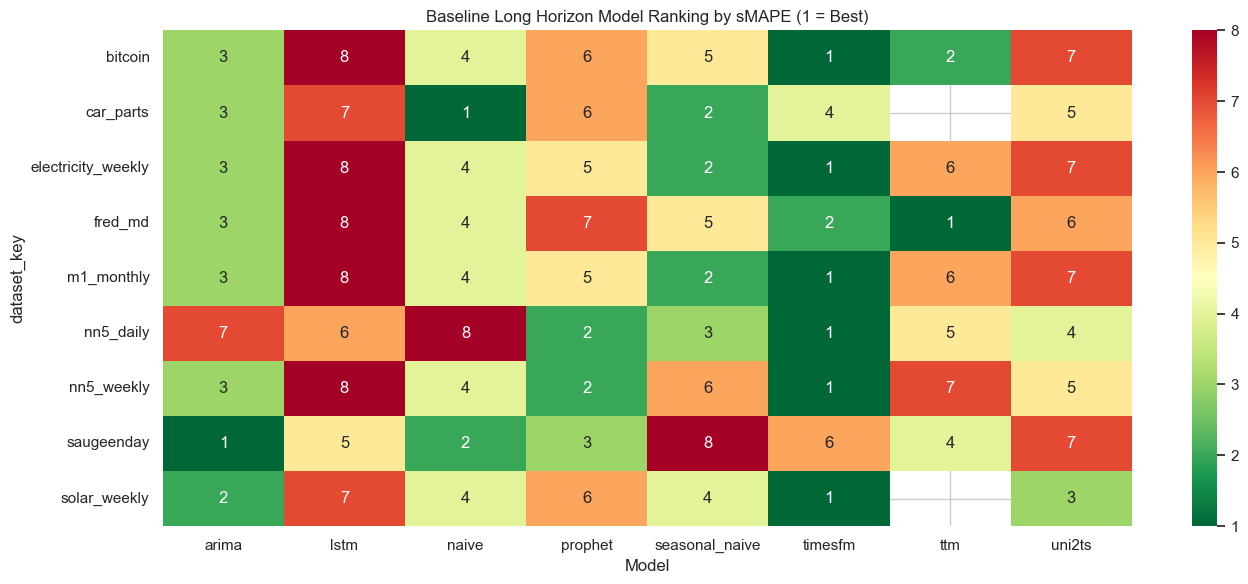

In [10]:
pivot_baseline_long_rank = baseline_long_rank.pivot_table(
    index="dataset_key",
    columns="model",
    values="smape_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_baseline_long_rank,
    title="Baseline Long Horizon Model Ranking by sMAPE (1 = Best)",
    cmap="RdYlGn_r",
    fmt=".0f",
)

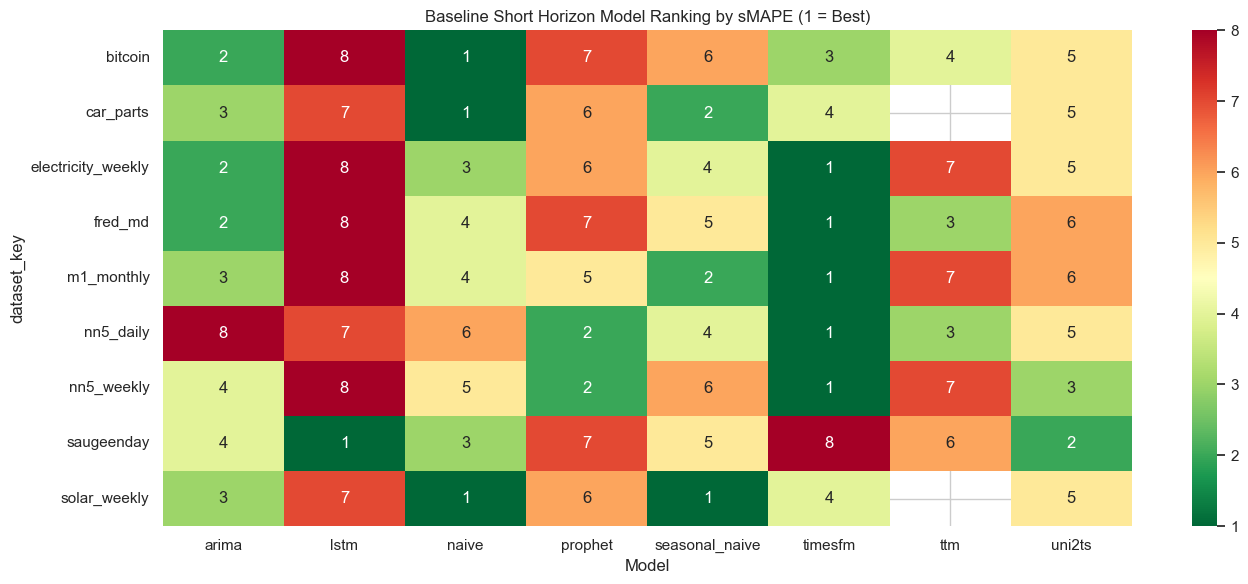

In [11]:
pivot_baseline_short_rank = baseline_short_rank.pivot_table(
    index="dataset_key",
    columns="model",
    values="smape_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_baseline_short_rank,
    title="Baseline Short Horizon Model Ranking by sMAPE (1 = Best)",
    cmap="RdYlGn_r",
    fmt=".0f",
)

In [12]:
tuned_rank_df = add_rank_column(
    df=tuned_df,
    group_cols=["dataset_key", "horizon_type"],
    value_col="smape",
    rank_col="smape_rank",
    ascending=True,
)

tuned_long_rank = tuned_rank_df[
    tuned_rank_df["horizon_type"] == "long"
].copy()

tuned_short_rank = tuned_rank_df[
    tuned_rank_df["horizon_type"] == "short"
].copy()

display(tuned_long_rank.head())
display(tuned_short_rank.head())

,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,smape_rank
8,bitcoin,finance,daily,timesfm,foundation,long,30,tuned,18,2.324739e+18,2.411559e+18,20.583393,2.197822e-04,0.731284,0.731510,0.109180,1.0
9,bitcoin,finance,daily,ttm,foundation,long,30,tuned,18,1.878327e+18,1.958246e+18,20.794301,3.298124e-06,0.141125,0.141134,0.991271,2.0
10,bitcoin,finance,daily,naive,traditional,long,30,tuned,18,7.777283e+17,9.419842e+17,21.785472,1.059638e-06,0.000012,0.000015,0.041874,3.0
11,bitcoin,finance,daily,seasonal_naive,traditional,long,30,tuned,18,1.773389e+18,1.963737e+18,22.063132,9.139379e-07,0.000117,0.000120,0.049374,4.0
12,bitcoin,finance,daily,arima,traditional,long,30,tuned,18,1.548943e+18,1.640359e+18,29.214567,1.708666e-06,1.046057,1.046062,37.667662,5.0


,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type,n_series,mae,rmse,smape,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,smape_rank
24,bitcoin,finance,daily,naive,traditional,short,15,tuned,18,4.294407e+17,5.332994e+17,22.977770,0.000001,0.000010,0.000013,0.041214,1.0
25,bitcoin,finance,daily,ttm,foundation,short,15,tuned,18,3.361518e+17,4.291515e+17,24.197713,0.000002,0.112830,0.112834,0.984540,2.0
26,bitcoin,finance,daily,timesfm,foundation,short,15,tuned,18,2.659037e+17,3.143286e+17,24.543081,0.000105,0.469068,0.469177,0.097994,3.0
27,bitcoin,finance,daily,arima,traditional,short,15,tuned,18,5.496781e+17,6.522394e+17,25.199613,0.000002,1.203161,1.203167,30.396972,4.0
28,bitcoin,finance,daily,uni2ts,foundation,short,15,tuned,18,6.006868e+17,6.957163e+17,26.936124,0.000004,1.063150,1.063160,0.942210,5.0


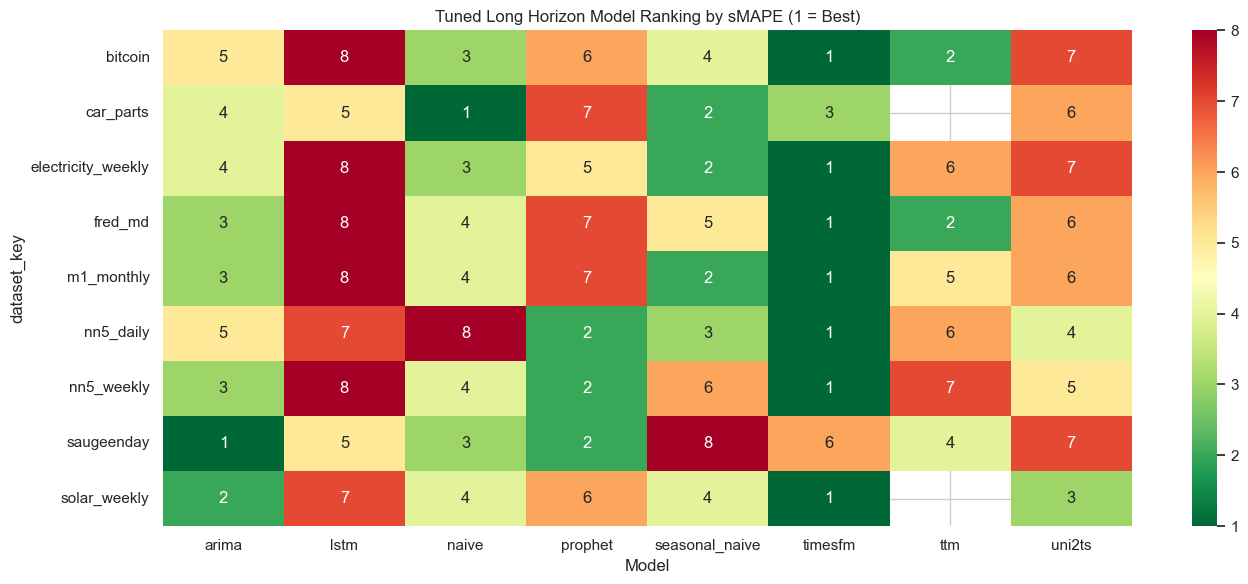

In [13]:
pivot_tuned_long_rank = tuned_long_rank.pivot_table(
    index="dataset_key",
    columns="model",
    values="smape_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_tuned_long_rank,
    title="Tuned Long Horizon Model Ranking by sMAPE (1 = Best)",
    cmap="RdYlGn_r",
    fmt=".0f",
)

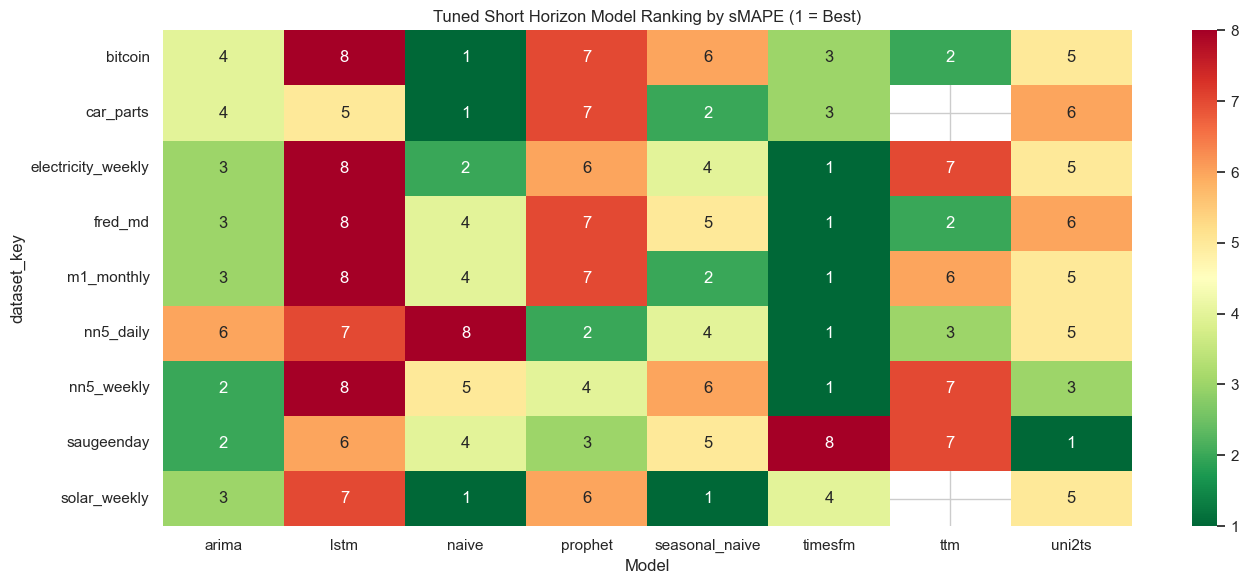

In [14]:
pivot_tuned_short_rank = tuned_short_rank.pivot_table(
    index="dataset_key",
    columns="model",
    values="smape_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_tuned_short_rank,
    title="Tuned Short Horizon Model Ranking by sMAPE (1 = Best)",
    cmap="RdYlGn_r",
    fmt=".0f",
)

In [15]:
best_baseline_by_smape = (
    baseline_df
    .sort_values(["dataset_key", "horizon_type", "smape"])
    .groupby(["dataset_key", "horizon_type"])
    .first()
    .reset_index()
)

best_tuned_by_smape = (
    tuned_df
    .sort_values(["dataset_key", "horizon_type", "smape"])
    .groupby(["dataset_key", "horizon_type"])
    .first()
    .reset_index()
)

print("Best baseline models:")
display(best_baseline_by_smape[
    ["dataset_key", "domain", "horizon_type", "model", "model_family", "n_series", "mae", "rmse", "smape"]
])

print("Best tuned models:")
display(best_tuned_by_smape[
    ["dataset_key", "domain", "horizon_type", "model", "model_family", "n_series", "mae", "rmse", "smape"]
])

Best baseline models:


,dataset_key,domain,horizon_type,model,model_family,n_series,mae,rmse,smape
0,bitcoin,finance,long,timesfm,foundation,18,2.324739e+18,2.411559e+18,20.583393
1,bitcoin,finance,short,naive,traditional,18,4.294407e+17,5.332994e+17,22.977770
2,car_parts,retail,long,naive,traditional,2674,5.727001e-01,7.505348e-01,53.131081
3,car_parts,retail,short,naive,traditional,2674,5.046746e-01,5.875446e-01,48.587146
4,electricity_weekly,energy,long,timesfm,foundation,321,3.048179e+04,3.313778e+04,9.103093
5,electricity_weekly,energy,short,timesfm,foundation,321,1.731972e+04,2.020527e+04,7.202438
6,fred_md,finance,long,ttm,foundation,107,4.281676e+03,4.936726e+03,12.239916
7,fred_md,finance,short,timesfm,foundation,107,2.769742e+03,3.203210e+03,10.291124
8,m1_monthly,finance,long,timesfm,foundation,589,1.958028e+03,2.297191e+03,13.982878
9,m1_monthly,finance,short,timesfm,foundation,617,1.305961e+03,1.602497e+03,11.438035


Best tuned models:


,dataset_key,domain,horizon_type,model,model_family,n_series,mae,rmse,smape
0,bitcoin,finance,long,timesfm,foundation,18,2.324739e+18,2.411559e+18,20.583393
1,bitcoin,finance,short,naive,traditional,18,4.294407e+17,5.332994e+17,22.977770
2,car_parts,retail,long,naive,traditional,2674,5.727001e-01,7.505348e-01,53.131081
3,car_parts,retail,short,naive,traditional,2674,5.046746e-01,5.875446e-01,48.587146
4,electricity_weekly,energy,long,timesfm,foundation,321,3.048179e+04,3.313778e+04,9.103093
5,electricity_weekly,energy,short,timesfm,foundation,321,1.731972e+04,2.020527e+04,7.202438
6,fred_md,finance,long,timesfm,foundation,107,5.015487e+03,5.732564e+03,13.074179
7,fred_md,finance,short,timesfm,foundation,107,2.769742e+03,3.203210e+03,10.291124
8,m1_monthly,finance,long,timesfm,foundation,589,1.958028e+03,2.297191e+03,13.982878
9,m1_monthly,finance,short,timesfm,foundation,617,1.305961e+03,1.602497e+03,11.438035


In [16]:
baseline_win_counts = (
    best_baseline_by_smape
    .groupby(["model", "model_family"])
    .size()
    .reset_index(name="baseline_wins")
    .sort_values("baseline_wins", ascending=False)
)

tuned_win_counts = (
    best_tuned_by_smape
    .groupby(["model", "model_family"])
    .size()
    .reset_index(name="tuned_wins")
    .sort_values("tuned_wins", ascending=False)
)

display(baseline_win_counts)
display(tuned_win_counts)

,model,model_family,baseline_wins
3,timesfm,foundation,11
2,naive,traditional,4
0,arima,traditional,1
1,lstm,traditional,1
4,ttm,foundation,1


,model,model_family,tuned_wins
2,timesfm,foundation,12
1,naive,traditional,4
0,arima,traditional,1
3,uni2ts,foundation,1


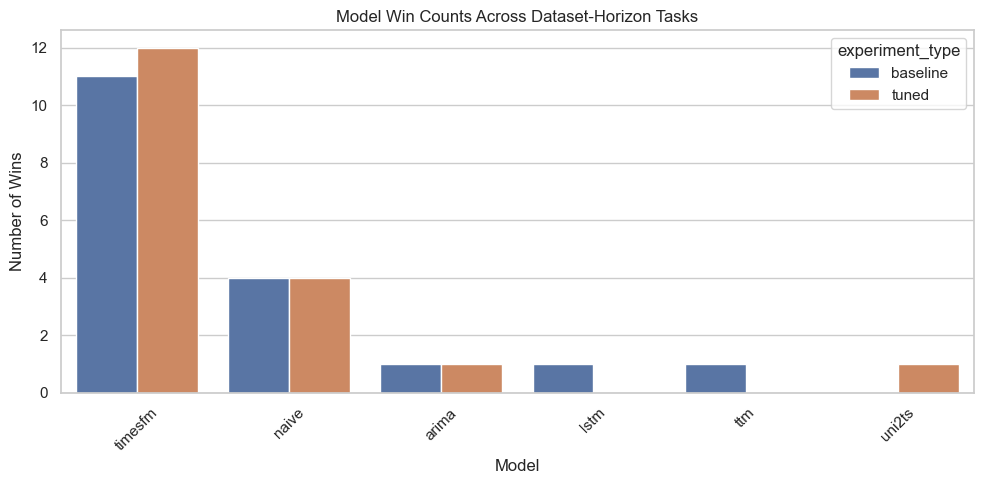

In [17]:
win_counts_combined = baseline_win_counts.merge(
    tuned_win_counts,
    on=["model", "model_family"],
    how="outer"
).fillna(0)

win_counts_long = win_counts_combined.melt(
    id_vars=["model", "model_family"],
    value_vars=["baseline_wins", "tuned_wins"],
    var_name="experiment_type",
    value_name="wins"
)

win_counts_long["experiment_type"] = win_counts_long["experiment_type"].replace({
    "baseline_wins": "baseline",
    "tuned_wins": "tuned",
})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=win_counts_long,
    x="model",
    y="wins",
    hue="experiment_type",
)

plt.title("Model Win Counts Across Dataset-Horizon Tasks")
plt.xlabel("Model")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
def overall_model_ranking(df: pd.DataFrame, experiment_label: str) -> pd.DataFrame:
    """
    Overall model ranking using average sMAPE rank across dataset-horizon tasks.
    Lower avg_rank is better.
    """
    rank_df = df.copy()

    rank_df["smape_rank"] = rank_df.groupby(
        ["dataset_key", "horizon_type"]
    )["smape"].rank(method="min", ascending=True)

    wins_df = (
        rank_df[rank_df["smape_rank"] == 1]
        .groupby(["model", "model_family"])
        .size()
        .reset_index(name="wins")
    )

    summary_df = (
        rank_df
        .groupby(["model", "model_family"])
        .agg(
            avg_rank=("smape_rank", "mean"),
            median_rank=("smape_rank", "median"),
            avg_smape=("smape", "mean"),
            avg_mae=("mae", "mean"),
            avg_rmse=("rmse", "mean"),
            evaluated_tasks=("smape_rank", "count"),
        )
        .reset_index()
        .merge(wins_df, on=["model", "model_family"], how="left")
    )

    summary_df["wins"] = summary_df["wins"].fillna(0).astype(int)
    summary_df["experiment_type"] = experiment_label

    return summary_df.sort_values(
        ["avg_rank", "wins"],
        ascending=[True, False]
    ).reset_index(drop=True)


overall_baseline_rank = overall_model_ranking(baseline_df, "baseline")
overall_tuned_rank = overall_model_ranking(tuned_df, "tuned")

print("Overall baseline ranking:")
display(overall_baseline_rank)

print("Overall tuned ranking:")
display(overall_tuned_rank)

Overall baseline ranking:


,model,model_family,avg_rank,median_rank,avg_smape,avg_mae,avg_rmse,evaluated_tasks,wins,experiment_type
0,timesfm,foundation,2.333333,1.0,31.533100,1.439246e+17,1.514382e+17,18,11,baseline
1,arima,traditional,3.277778,3.0,29.305981,9.162557e+16,1.040810e+17,18,1,baseline
2,naive,traditional,3.500000,4.0,27.626282,6.706494e+16,8.196020e+16,18,4,baseline
3,seasonal_naive,traditional,4.000000,4.0,28.777589,1.410529e+17,1.633292e+17,18,1,baseline
4,ttm,foundation,4.857143,5.5,25.126622,1.552850e+17,1.642951e+17,14,1,baseline
5,prophet,traditional,5.000000,6.0,47.667473,4.291923e+17,4.319399e+17,18,0,baseline
6,uni2ts,foundation,5.166667,5.0,45.563185,2.257255e+17,2.381644e+17,18,0,baseline
7,lstm,traditional,7.055556,8.0,149.979504,6.007436e+17,6.028764e+17,18,1,baseline


Overall tuned ranking:


,model,model_family,avg_rank,median_rank,avg_smape,avg_mae,avg_rmse,evaluated_tasks,wins,experiment_type
0,timesfm,foundation,2.166667,1.0,31.533100,1.439246e+17,1.514382e+17,18,12,tuned
1,arima,traditional,3.333333,3.0,40.428861,1.165900e+17,1.273666e+17,18,1,tuned
2,naive,traditional,3.555556,4.0,27.626282,6.706494e+16,8.196020e+16,18,4,tuned
3,seasonal_naive,traditional,3.944444,4.0,28.777589,1.410529e+17,1.633292e+17,18,1,tuned
4,ttm,foundation,4.714286,5.5,25.443977,1.581771e+17,1.705284e+17,14,0,tuned
5,uni2ts,foundation,5.111111,5.0,45.245690,2.256102e+17,2.336525e+17,18,1,tuned
6,prophet,traditional,5.166667,6.0,52.821385,4.259737e+17,4.287414e+17,18,0,tuned
7,lstm,traditional,7.166667,8.0,137.789358,6.007436e+17,6.028764e+17,18,0,tuned


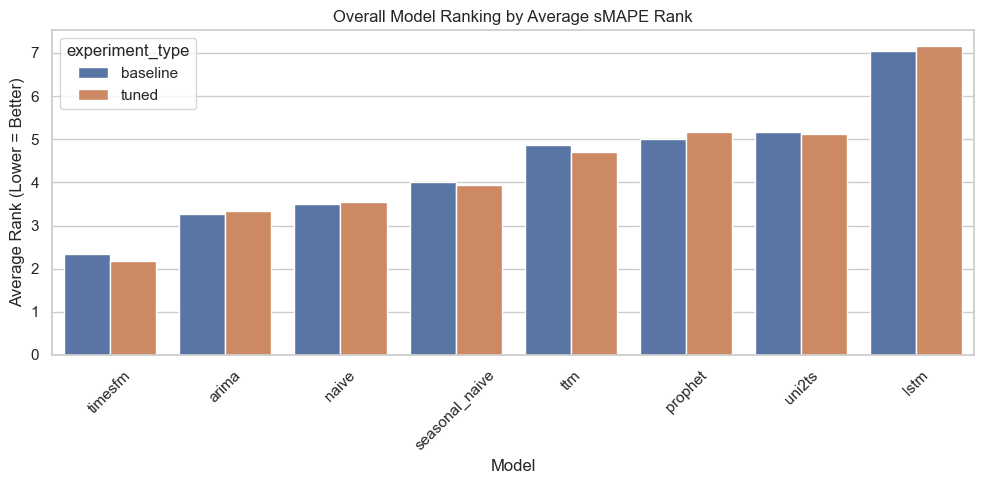

In [19]:
overall_rank_combined = pd.concat(
    [overall_baseline_rank, overall_tuned_rank],
    ignore_index=True,
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=overall_rank_combined,
    x="model",
    y="avg_rank",
    hue="experiment_type",
)

plt.title("Overall Model Ranking by Average sMAPE Rank")
plt.xlabel("Model")
plt.ylabel("Average Rank (Lower = Better)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
domain_rank_df = accuracy_experiment_df.copy()

domain_rank_df["smape_rank"] = domain_rank_df.groupby(
    ["dataset_key", "horizon_type", "experiment_type"]
)["smape"].rank(method="min", ascending=True)

domain_model_rank_summary = (
    domain_rank_df
    .groupby(["domain", "model", "model_family", "experiment_type"])
    .agg(
        avg_domain_rank=("smape_rank", "mean"),
        median_domain_rank=("smape_rank", "median"),
        evaluated_tasks=("smape_rank", "count"),
        avg_smape=("smape", "mean"),
    )
    .reset_index()
    .sort_values(["experiment_type", "domain", "avg_domain_rank"])
)

domain_model_rank_summary.head(30)

,domain,model,model_family,experiment_type,avg_domain_rank,median_domain_rank,evaluated_tasks,avg_smape
0,energy,arima,traditional,baseline,2.500000,2.5,6,28.327166
4,energy,naive,traditional,baseline,2.833333,3.0,6,28.075019
10,energy,timesfm,foundation,baseline,3.500000,2.5,6,31.322050
8,energy,seasonal_naive,traditional,baseline,4.000000,4.0,6,33.195209
14,energy,uni2ts,foundation,baseline,4.833333,5.0,6,35.388773
6,energy,prophet,traditional,baseline,5.500000,6.0,6,37.938500
12,energy,ttm,foundation,baseline,5.750000,6.0,4,34.664544
2,energy,lstm,traditional,baseline,6.000000,7.0,6,149.475048
26,finance,timesfm,foundation,baseline,1.500000,1.0,6,15.652115
16,finance,arima,traditional,baseline,2.666667,3.0,6,17.483864


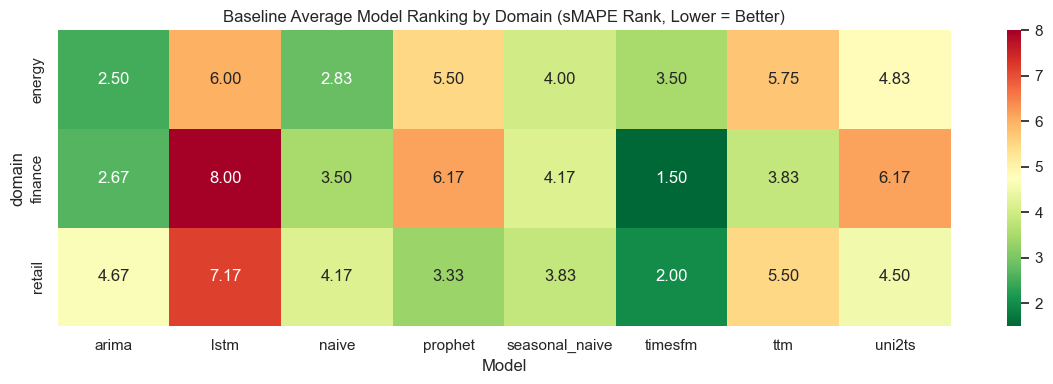

In [21]:
domain_baseline_rank = domain_model_rank_summary[
    domain_model_rank_summary["experiment_type"] == "baseline"
].copy()

pivot_domain_baseline_rank = domain_baseline_rank.pivot_table(
    index="domain",
    columns="model",
    values="avg_domain_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_domain_baseline_rank,
    title="Baseline Average Model Ranking by Domain (sMAPE Rank, Lower = Better)",
    cmap="RdYlGn_r",
    fmt=".2f",
    figsize=(12, 4),
)

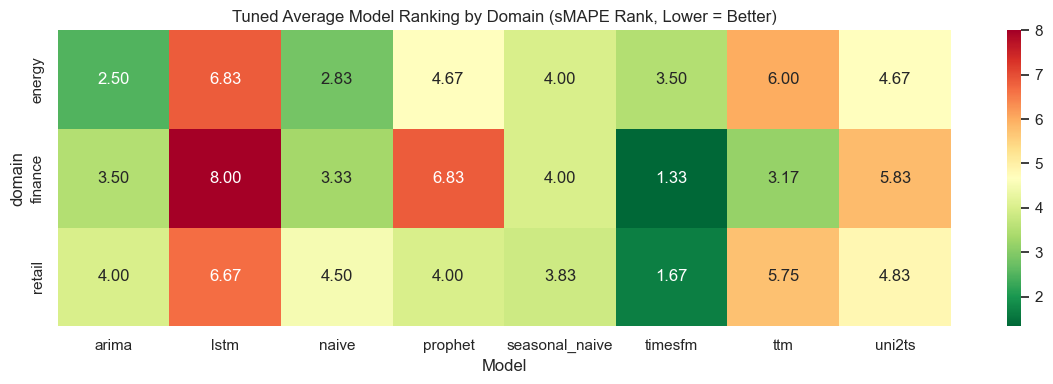

In [22]:
domain_tuned_rank = domain_model_rank_summary[
    domain_model_rank_summary["experiment_type"] == "tuned"
].copy()

pivot_domain_tuned_rank = domain_tuned_rank.pivot_table(
    index="domain",
    columns="model",
    values="avg_domain_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_domain_tuned_rank,
    title="Tuned Average Model Ranking by Domain (sMAPE Rank, Lower = Better)",
    cmap="RdYlGn_r",
    fmt=".2f",
    figsize=(12, 4),
)

In [23]:
best_domain_baseline = (
    domain_baseline_rank
    .sort_values(["domain", "avg_domain_rank"])
    .groupby("domain")
    .first()
    .reset_index()
)

best_domain_tuned = (
    domain_tuned_rank
    .sort_values(["domain", "avg_domain_rank"])
    .groupby("domain")
    .first()
    .reset_index()
)

print("Best baseline model per domain:")
display(best_domain_baseline[
    ["domain", "model", "model_family", "avg_domain_rank", "evaluated_tasks", "avg_smape"]
])

print("Best tuned model per domain:")
display(best_domain_tuned[
    ["domain", "model", "model_family", "avg_domain_rank", "evaluated_tasks", "avg_smape"]
])

Best baseline model per domain:


,domain,model,model_family,avg_domain_rank,evaluated_tasks,avg_smape
0,energy,arima,traditional,2.5,6,28.327166
1,finance,timesfm,foundation,1.5,6,15.652115
2,retail,timesfm,foundation,2.0,6,47.625134


Best tuned model per domain:


,domain,model,model_family,avg_domain_rank,evaluated_tasks,avg_smape
0,energy,arima,traditional,2.500000,6,27.199124
1,finance,timesfm,foundation,1.333333,6,15.652115
2,retail,timesfm,foundation,1.666667,6,47.625134


In [24]:
comparison_df = baseline_df.merge(
    tuned_df,
    on=[
        "dataset_key",
        "domain",
        "frequency",
        "model",
        "model_family",
        "horizon_type",
        "horizon",
    ],
    suffixes=("_baseline", "_tuned"),
    how="inner",
)

comparison_df["smape_improvement"] = (
    comparison_df["smape_baseline"] - comparison_df["smape_tuned"]
)

comparison_df["mae_improvement"] = (
    comparison_df["mae_baseline"] - comparison_df["mae_tuned"]
)

comparison_df["rmse_improvement"] = (
    comparison_df["rmse_baseline"] - comparison_df["rmse_tuned"]
)

comparison_df.head()

,dataset_key,domain,frequency,model,model_family,horizon_type,horizon,experiment_type_baseline,n_series_baseline,mae_baseline,rmse_baseline,smape_baseline,avg_fit_time_seconds_baseline,avg_inference_time_seconds_baseline,avg_series_total_time_seconds_baseline,avg_peak_memory_mb_baseline,experiment_type_tuned,n_series_tuned,mae_tuned,rmse_tuned,smape_tuned,avg_fit_time_seconds_tuned,avg_inference_time_seconds_tuned,avg_series_total_time_seconds_tuned,avg_peak_memory_mb_tuned,smape_improvement,mae_improvement,rmse_improvement
0,bitcoin,finance,daily,timesfm,foundation,long,30,baseline,18,2.324739e+18,2.411559e+18,20.583393,1.748933e-04,0.454365,0.454548,0.102420,tuned,18,2.324739e+18,2.411559e+18,20.583393,2.197822e-04,0.731284,0.731510,0.109180,0.000000,0.000000e+00,0.000000e+00
1,bitcoin,finance,daily,ttm,foundation,long,30,baseline,18,1.898523e+18,1.982594e+18,21.082188,3.192160e-06,0.110597,0.110605,0.988549,tuned,18,1.878327e+18,1.958246e+18,20.794301,3.298124e-06,0.141125,0.141134,0.991271,0.287888,2.019530e+16,2.434766e+16
2,bitcoin,finance,daily,arima,traditional,long,30,baseline,18,1.058520e+18,1.183484e+18,21.356206,1.629194e-06,0.225946,0.225951,15.732830,tuned,18,1.548943e+18,1.640359e+18,29.214567,1.708666e-06,1.046057,1.046062,37.667662,-7.858361,-4.904231e+17,-4.568741e+17
3,bitcoin,finance,daily,naive,traditional,long,30,baseline,18,7.777283e+17,9.419842e+17,21.785472,8.344650e-07,0.000012,0.000015,0.041874,tuned,18,7.777283e+17,9.419842e+17,21.785472,1.059638e-06,0.000012,0.000015,0.041874,0.000000,0.000000e+00,0.000000e+00
4,bitcoin,finance,daily,seasonal_naive,traditional,long,30,baseline,18,1.773389e+18,1.963737e+18,22.063132,6.887648e-07,0.000106,0.000109,0.049374,tuned,18,1.773389e+18,1.963737e+18,22.063132,9.139379e-07,0.000117,0.000120,0.049374,0.000000,0.000000e+00,0.000000e+00


In [25]:
tuning_summary = (
    comparison_df
    .groupby(["model", "model_family"])
    .agg(
        mean_smape_improvement=("smape_improvement", "mean"),
        median_smape_improvement=("smape_improvement", "median"),
        improved_tasks=("smape_improvement", lambda x: (x > 0).sum()),
        worsened_tasks=("smape_improvement", lambda x: (x < 0).sum()),
        unchanged_tasks=("smape_improvement", lambda x: (x == 0).sum()),
        evaluated_tasks=("smape_improvement", "count"),
    )
    .reset_index()
    .sort_values("mean_smape_improvement", ascending=False)
)

tuning_summary

,model,model_family,mean_smape_improvement,median_smape_improvement,improved_tasks,worsened_tasks,unchanged_tasks,evaluated_tasks
1,lstm,traditional,12.190146,8.609025,16,2,0,18
7,uni2ts,foundation,0.317496,0.043500,11,7,0,18
2,naive,traditional,0.000000,0.000000,0,0,18,18
4,seasonal_naive,traditional,0.000000,0.000000,0,0,18,18
5,timesfm,foundation,0.000000,0.000000,0,0,18,18
6,ttm,foundation,-0.317355,0.000000,5,5,4,14
3,prophet,traditional,-5.153912,0.220806,11,7,0,18
0,arima,traditional,-11.122880,0.442994,11,7,0,18


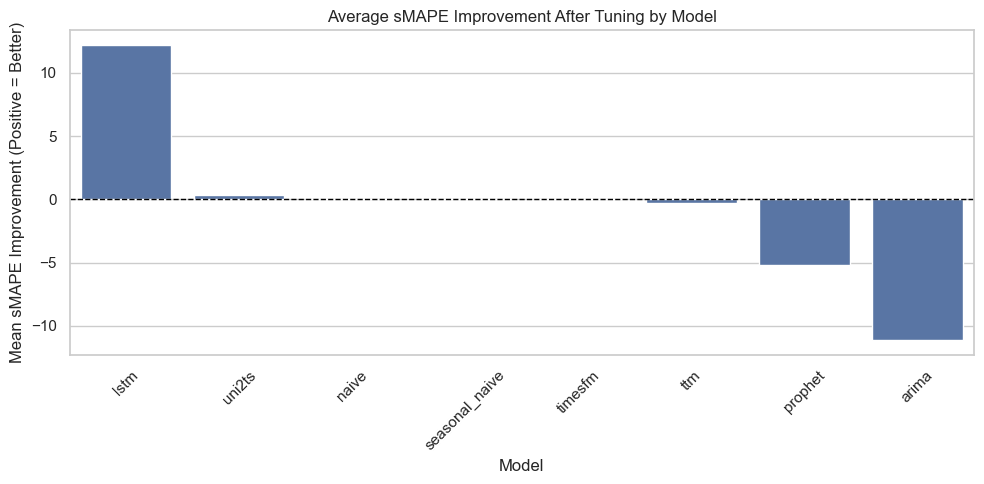

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tuning_summary,
    x="model",
    y="mean_smape_improvement",
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Average sMAPE Improvement After Tuning by Model")
plt.xlabel("Model")
plt.ylabel("Mean sMAPE Improvement (Positive = Better)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
runtime_model_summary = (
    accuracy_experiment_df
    .groupby(["model", "model_family"])
    .agg(
        avg_fit_time_seconds=("avg_fit_time_seconds", "mean"),
        avg_inference_time_seconds=("avg_inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("avg_series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
        evaluated_tasks=("avg_series_total_time_seconds", "count"),
    )
    .reset_index()
    .sort_values("avg_series_total_time_seconds")
)

runtime_model_summary

,model,model_family,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,evaluated_tasks
2,naive,traditional,0.000001,0.000013,0.000017,3.761858,36
4,seasonal_naive,traditional,0.000001,0.000125,0.000129,0.599709,36
0,arima,traditional,0.000002,0.454594,0.454601,12.103930,36
6,ttm,foundation,0.000004,0.637588,0.637597,11.737877,28
5,timesfm,foundation,0.000138,0.649844,0.649989,3.900383,36
7,uni2ts,foundation,0.000003,1.212313,1.212321,4.768444,36
3,prophet,traditional,0.000098,1.569384,1.569489,106.563346,36
1,lstm,traditional,0.000004,54.599933,54.599948,2.438062,36


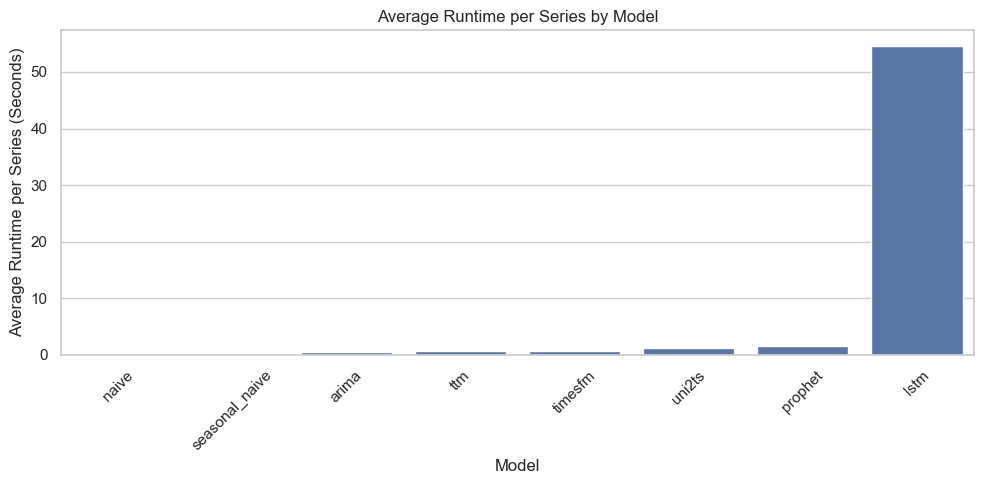

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=runtime_model_summary,
    x="model",
    y="avg_series_total_time_seconds",
)

plt.title("Average Runtime per Series by Model")
plt.xlabel("Model")
plt.ylabel("Average Runtime per Series (Seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

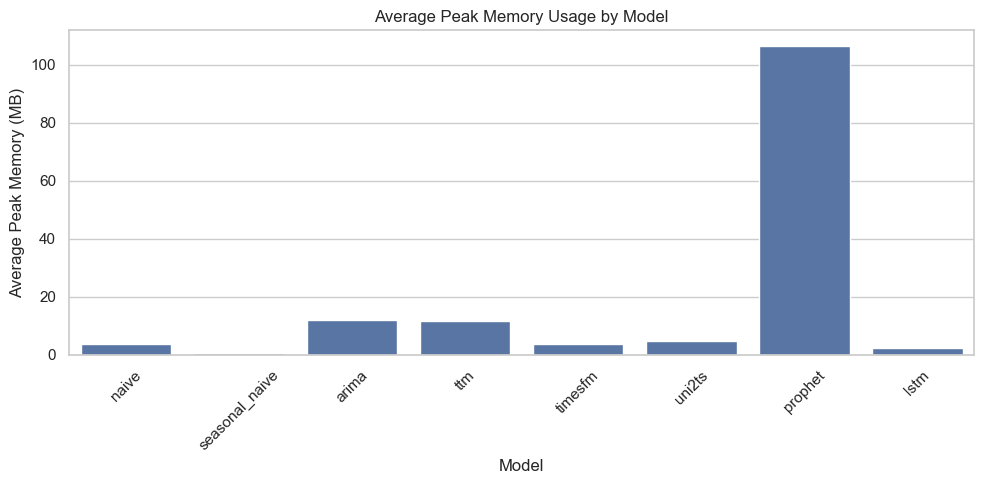

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=runtime_model_summary,
    x="model",
    y="avg_peak_memory_mb",
)

plt.title("Average Peak Memory Usage by Model")
plt.xlabel("Model")
plt.ylabel("Average Peak Memory (MB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

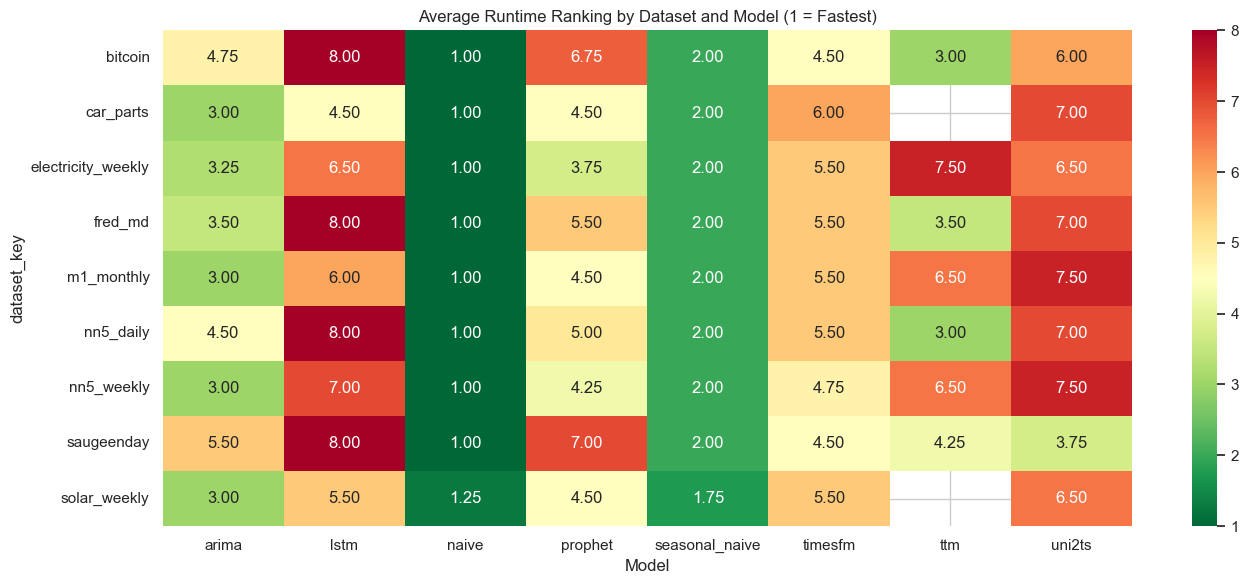

In [30]:
runtime_dataset_rank_df = accuracy_experiment_df.copy()

runtime_dataset_rank_df["runtime_rank"] = runtime_dataset_rank_df.groupby(
    ["dataset_key", "horizon_type", "experiment_type"]
)["avg_series_total_time_seconds"].rank(method="min", ascending=True)

runtime_dataset_rank_summary = (
    runtime_dataset_rank_df
    .groupby(["dataset_key", "model"])
    .agg(
        avg_runtime_rank=("runtime_rank", "mean"),
        avg_runtime_seconds=("avg_series_total_time_seconds", "mean"),
    )
    .reset_index()
)

pivot_runtime_dataset_rank = runtime_dataset_rank_summary.pivot_table(
    index="dataset_key",
    columns="model",
    values="avg_runtime_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_runtime_dataset_rank,
    title="Average Runtime Ranking by Dataset and Model (1 = Fastest)",
    cmap="RdYlGn_r",
    fmt=".2f",
)

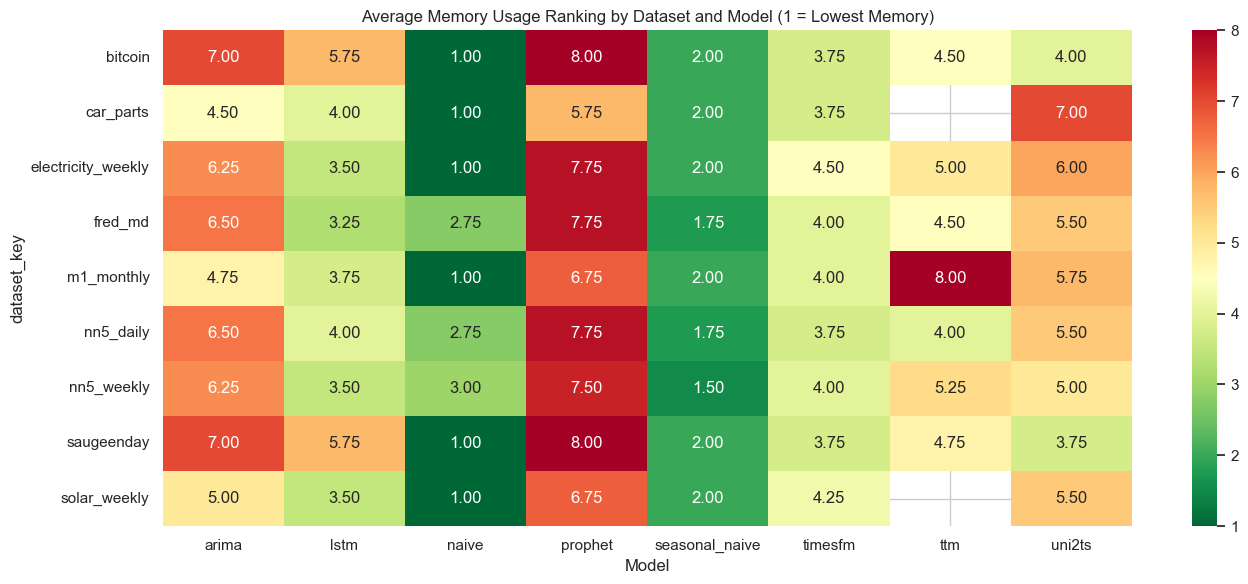

In [31]:
memory_dataset_rank_df = accuracy_experiment_df.copy()

memory_dataset_rank_df["memory_rank"] = memory_dataset_rank_df.groupby(
    ["dataset_key", "horizon_type", "experiment_type"]
)["avg_peak_memory_mb"].rank(method="min", ascending=True)

memory_dataset_rank_summary = (
    memory_dataset_rank_df
    .groupby(["dataset_key", "model"])
    .agg(
        avg_memory_rank=("memory_rank", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
    )
    .reset_index()
)

pivot_memory_dataset_rank = memory_dataset_rank_summary.pivot_table(
    index="dataset_key",
    columns="model",
    values="avg_memory_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_memory_dataset_rank,
    title="Average Memory Usage Ranking by Dataset and Model (1 = Lowest Memory)",
    cmap="RdYlGn_r",
    fmt=".2f",
)

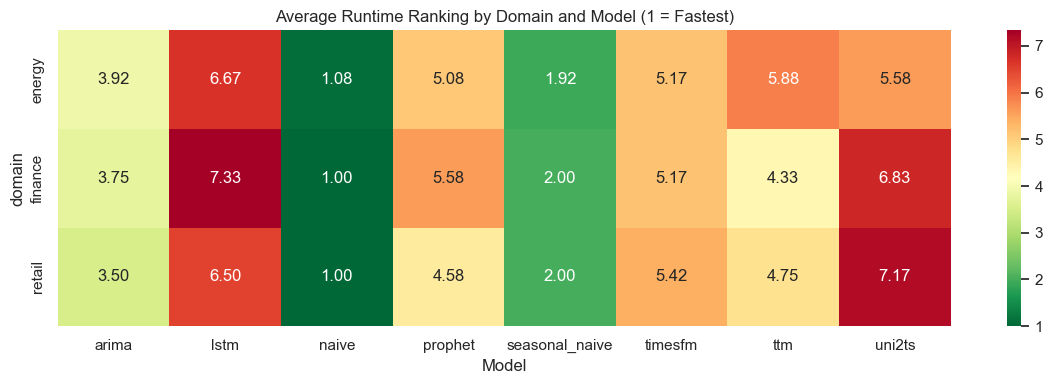

In [32]:
runtime_domain_rank_summary = (
    runtime_dataset_rank_df
    .groupby(["domain", "model", "model_family"])
    .agg(
        avg_runtime_rank=("runtime_rank", "mean"),
        avg_runtime_seconds=("avg_series_total_time_seconds", "mean"),
    )
    .reset_index()
)

pivot_runtime_domain_rank = runtime_domain_rank_summary.pivot_table(
    index="domain",
    columns="model",
    values="avg_runtime_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_runtime_domain_rank,
    title="Average Runtime Ranking by Domain and Model (1 = Fastest)",
    cmap="RdYlGn_r",
    fmt=".2f",
    figsize=(12, 4),
)

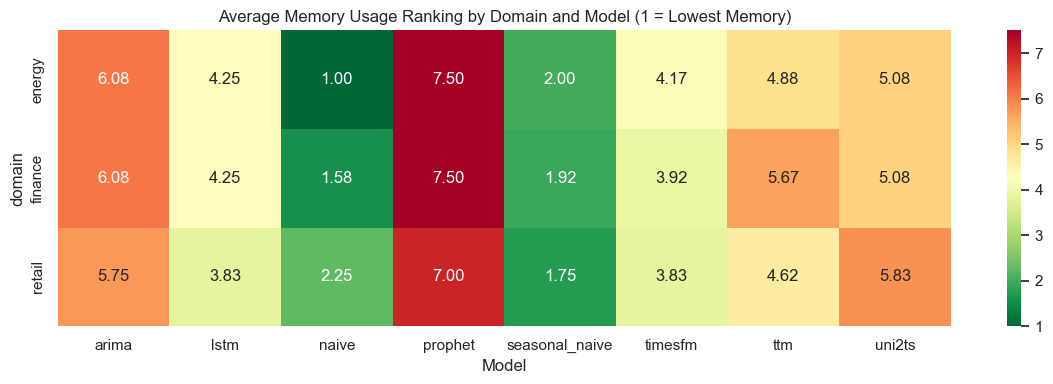

In [33]:
memory_domain_rank_summary = (
    memory_dataset_rank_df
    .groupby(["domain", "model", "model_family"])
    .agg(
        avg_memory_rank=("memory_rank", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
    )
    .reset_index()
)

pivot_memory_domain_rank = memory_domain_rank_summary.pivot_table(
    index="domain",
    columns="model",
    values="avg_memory_rank",
    aggfunc="mean",
)

plot_heatmap(
    pivot_memory_domain_rank,
    title="Average Memory Usage Ranking by Domain and Model (1 = Lowest Memory)",
    cmap="RdYlGn_r",
    fmt=".2f",
    figsize=(12, 4),
)

In [34]:
rank_for_tradeoff = accuracy_experiment_df.copy()

rank_for_tradeoff["smape_rank"] = rank_for_tradeoff.groupby(
    ["dataset_key", "horizon_type", "experiment_type"]
)["smape"].rank(method="min", ascending=True)

accuracy_runtime_tradeoff = (
    rank_for_tradeoff
    .groupby(["model", "model_family"])
    .agg(
        avg_smape_rank=("smape_rank", "mean"),
        avg_smape=("smape", "mean"),
        avg_runtime_seconds=("avg_series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
        evaluated_tasks=("smape_rank", "count"),
    )
    .reset_index()
    .sort_values("avg_smape_rank")
)

accuracy_runtime_tradeoff

,model,model_family,avg_smape_rank,avg_smape,avg_runtime_seconds,avg_peak_memory_mb,evaluated_tasks
5,timesfm,foundation,2.250000,31.533100,0.649989,3.900383,36
0,arima,traditional,3.305556,34.867421,0.454601,12.103930,36
2,naive,traditional,3.527778,27.626282,0.000017,3.761858,36
4,seasonal_naive,traditional,3.972222,28.777589,0.000129,0.599709,36
6,ttm,foundation,4.785714,25.285299,0.637597,11.737877,28
3,prophet,traditional,5.083333,50.244429,1.569489,106.563346,36
7,uni2ts,foundation,5.138889,45.404438,1.212321,4.768444,36
1,lstm,traditional,7.111111,143.884431,54.599948,2.438062,36


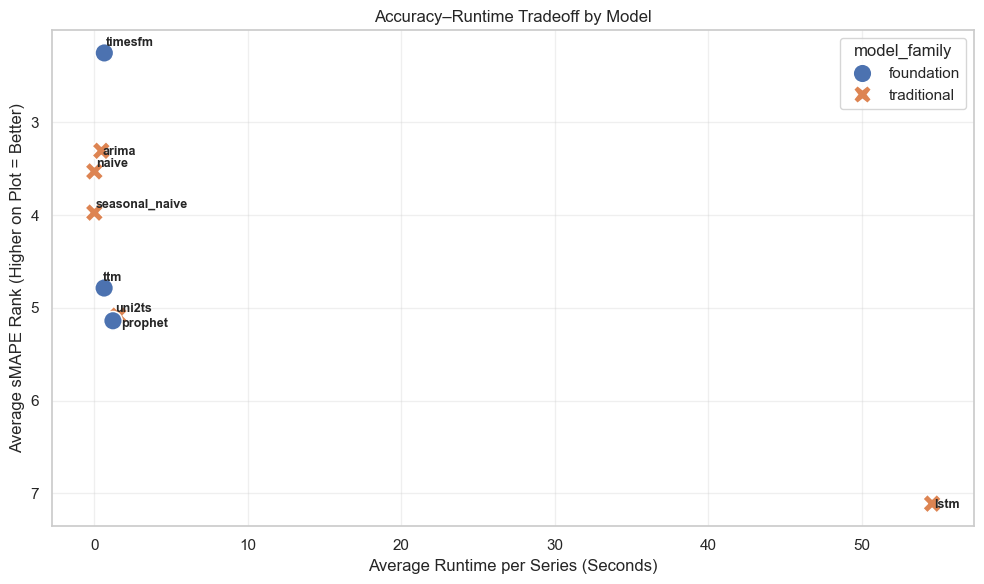

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=accuracy_runtime_tradeoff,
    x="avg_runtime_seconds",
    y="avg_smape_rank",
    hue="model_family",
    style="model_family",
    s=180,
)

# Manual offsets for overlapping labels
offsets = {
    "prophet": (0.15, 0.12),
    "uni2ts": (0.15, -0.10),
    "ttm": (-0.10, -0.08),
    "timesfm": (0.10, -0.08),
    "arima": (0.10, 0.05),
    "naive": (0.10, -0.05),
    "seasonal_naive": (0.10, -0.05),
    "lstm": (0.10, 0.05),
}

for _, row in accuracy_runtime_tradeoff.iterrows():

    dx, dy = offsets.get(row["model"], (0.05, 0.05))

    plt.text(
        row["avg_runtime_seconds"] + dx,
        row["avg_smape_rank"] + dy,
        row["model"],
        fontsize=9,
        weight="bold",
    )

plt.gca().invert_yaxis()

plt.title("Accuracy–Runtime Tradeoff by Model")
plt.xlabel("Average Runtime per Series (Seconds)")
plt.ylabel("Average sMAPE Rank (Higher on Plot = Better)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

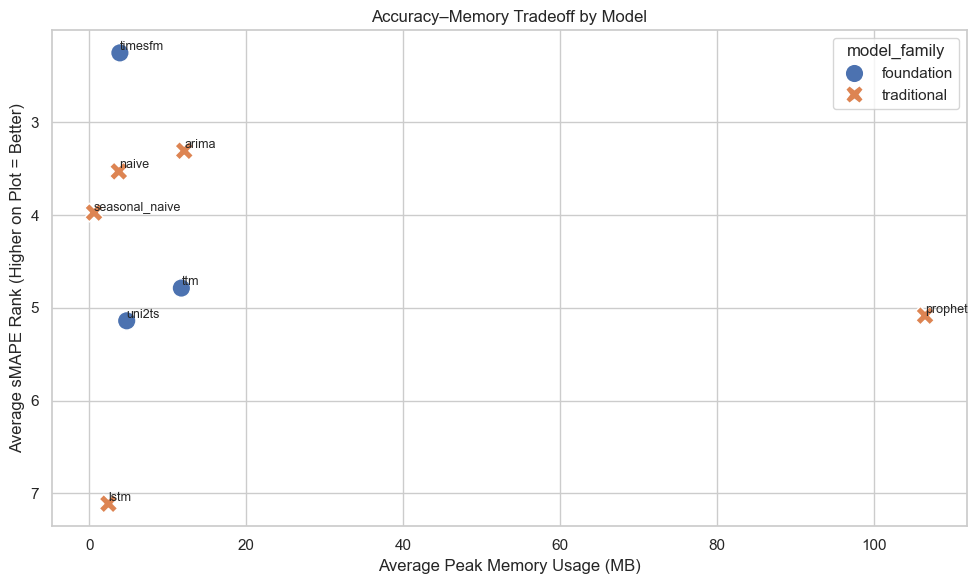

In [36]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=accuracy_runtime_tradeoff,
    x="avg_peak_memory_mb",
    y="avg_smape_rank",
    hue="model_family",
    style="model_family",
    s=180,
)

for _, row in accuracy_runtime_tradeoff.iterrows():
    plt.text(
        row["avg_peak_memory_mb"],
        row["avg_smape_rank"],
        row["model"],
        fontsize=9,
        ha="left",
        va="bottom",
    )

plt.gca().invert_yaxis()
plt.title("Accuracy–Memory Tradeoff by Model")
plt.xlabel("Average Peak Memory Usage (MB)")
plt.ylabel("Average sMAPE Rank (Higher on Plot = Better)")
plt.tight_layout()
plt.show()

In [37]:
if "status" in raw_df.columns:
    failure_summary = (
        raw_df
        .groupby(["dataset_key", "model", "horizon_type", "experiment_type", "status"])
        .size()
        .reset_index(name="count")
        .sort_values(["dataset_key", "model", "horizon_type", "experiment_type", "status"])
    )

    failed_model_summary = (
        raw_df[raw_df["status"] != "success"]
        .groupby(["model", "experiment_type"])
        .size()
        .reset_index(name="failed_runs")
        .sort_values("failed_runs", ascending=False)
    )

    print("Failure summary:")
    display(failure_summary)

    print("Failed model summary:")
    display(failed_model_summary)
else:
    print("No status column found in raw_df.")

Failure summary:


,dataset_key,model,horizon_type,experiment_type,status,count
0,bitcoin,arima,long,baseline,success,18
1,bitcoin,arima,long,tuned,success,18
2,bitcoin,arima,short,baseline,success,18
3,bitcoin,arima,short,tuned,success,18
4,bitcoin,lstm,long,baseline,success,18
...,...,...,...,...,...,...
293,solar_weekly,ttm,short,tuned,failed,137
294,solar_weekly,uni2ts,long,baseline,success,137
295,solar_weekly,uni2ts,long,tuned,success,137
296,solar_weekly,uni2ts,short,baseline,success,137


Failed model summary:


,model,experiment_type,failed_runs
2,ttm,baseline,6190
3,ttm,tuned,6190
0,timesfm,baseline,33
1,timesfm,tuned,33


In [38]:
accuracy_experiment_df.to_csv(FINAL_DIR / "accuracy_experiment_summary.csv", index=False)

baseline_df.to_csv(FINAL_DIR / "baseline_accuracy_summary.csv", index=False)
tuned_df.to_csv(FINAL_DIR / "tuned_accuracy_summary.csv", index=False)

best_baseline_by_smape.to_csv(FINAL_DIR / "best_baseline_by_smape.csv", index=False)
best_tuned_by_smape.to_csv(FINAL_DIR / "best_tuned_by_smape.csv", index=False)

baseline_win_counts.to_csv(FINAL_DIR / "baseline_win_counts.csv", index=False)
tuned_win_counts.to_csv(FINAL_DIR / "tuned_win_counts.csv", index=False)

overall_baseline_rank.to_csv(FINAL_DIR / "overall_baseline_rank_summary.csv", index=False)
overall_tuned_rank.to_csv(FINAL_DIR / "overall_tuned_rank_summary.csv", index=False)

domain_model_rank_summary.to_csv(FINAL_DIR / "domain_model_rank_summary.csv", index=False)
best_domain_baseline.to_csv(FINAL_DIR / "best_domain_baseline.csv", index=False)
best_domain_tuned.to_csv(FINAL_DIR / "best_domain_tuned.csv", index=False)

comparison_df.to_csv(FINAL_DIR / "baseline_vs_tuned_comparison.csv", index=False)
tuning_summary.to_csv(FINAL_DIR / "tuning_summary.csv", index=False)

runtime_model_summary.to_csv(FINAL_DIR / "runtime_model_summary.csv", index=False)
runtime_dataset_rank_summary.to_csv(FINAL_DIR / "runtime_dataset_rank_summary.csv", index=False)
memory_dataset_rank_summary.to_csv(FINAL_DIR / "memory_dataset_rank_summary.csv", index=False)
runtime_domain_rank_summary.to_csv(FINAL_DIR / "runtime_domain_rank_summary.csv", index=False)
memory_domain_rank_summary.to_csv(FINAL_DIR / "memory_domain_rank_summary.csv", index=False)

accuracy_runtime_tradeoff.to_csv(FINAL_DIR / "accuracy_runtime_tradeoff.csv", index=False)

if "status" in raw_df.columns:
    failure_summary.to_csv(FINAL_DIR / "failure_summary.csv", index=False)
    failed_model_summary.to_csv(FINAL_DIR / "failed_model_summary.csv", index=False)

print("Saved final outputs to:", FINAL_DIR)

Saved final outputs to: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/notebooks/results/final_analysis


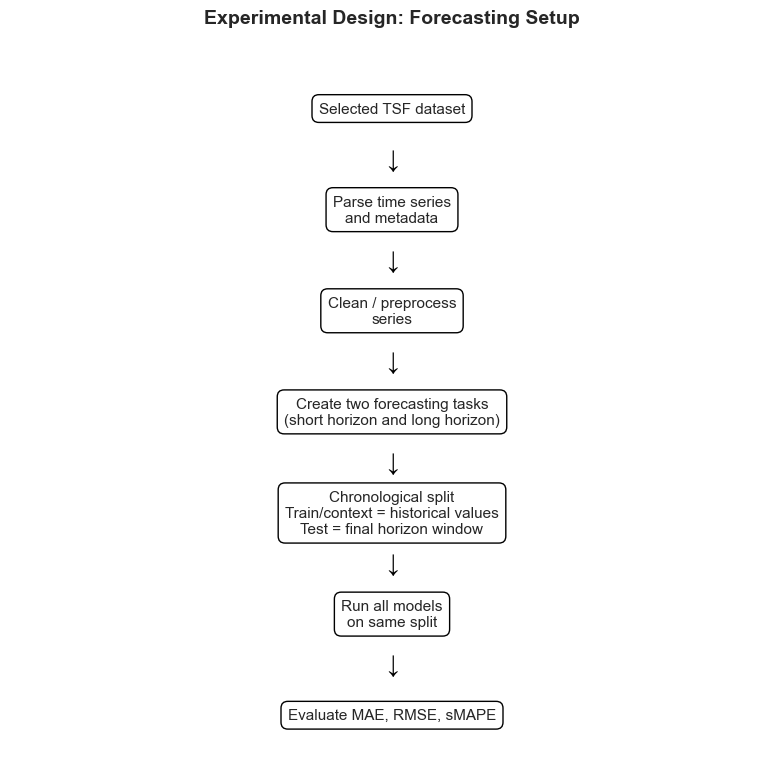

In [48]:
# FIGURE: TIME SERIES FORECASTING WORKFLOW DIAGRAM

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

ax.axis("off")

steps = [
    "Selected TSF dataset",
    "Parse time series\nand metadata",
    "Clean / preprocess\nseries",
    "Create two forecasting tasks\n(short horizon and long horizon)",
    "Chronological split\nTrain/context = historical values\nTest = final horizon window",
    "Run all models\non same split",
    "Evaluate MAE, RMSE, sMAPE"
]

y_positions = np.linspace(0.92, 0.08, len(steps))

for i, (step, y) in enumerate(zip(steps, y_positions)):

    ax.text(
        0.5,
        y,
        step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.45",
            edgecolor="black",
            facecolor="white"
        )
    )

    if i < len(steps) - 1:
        arrow_y = (y + y_positions[i + 1]) / 2

        ax.text(
            0.5,
            arrow_y,
            "↓",
            ha="center",
            va="center",
            fontsize=18,
            color="black"
        )

plt.title(
    "Experimental Design: Forecasting Setup",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

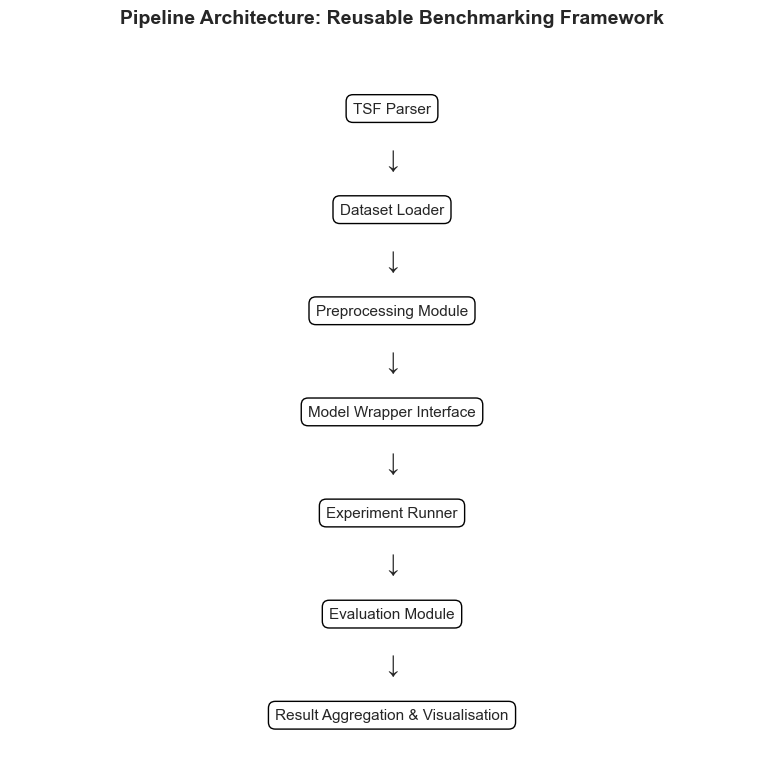

In [49]:
# FIGURE: TIME SERIES PIPELINE ARCHITECTURE
fig, ax = plt.subplots(figsize=(8, 8))

ax.axis("off")

steps = [
    "TSF Parser",
    "Dataset Loader",
    "Preprocessing Module",
    "Model Wrapper Interface",
    "Experiment Runner",
    "Evaluation Module",
    "Result Aggregation & Visualisation"
]

y_positions = np.linspace(0.92, 0.08, len(steps))

for i, (step, y) in enumerate(zip(steps, y_positions)):
    ax.text(
        0.5,
        y,
        step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.45",
            edgecolor="black",
            facecolor="white"
        )
    )

    if i < len(steps) - 1:
        ax.text(
            0.5,
            (y + y_positions[i + 1]) / 2,
            "↓",
            ha="center",
            va="center",
            fontsize=18
        )

plt.title(
    "Pipeline Architecture: Reusable Benchmarking Framework",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()